# 第 10 章 · ViT Patchify 代码实验

[章节网页](../ch10.html)

## 运行内容

- 加载真实照片
- 切分 16×16 patch token
- 绘制 patch 网格

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 使用 sklearn 内置真实照片 china.jpg，按 ViT 常见设置切成 16x16 patch。
raw_photo = load_sample_image("china.jpg")
vit_image = np.asarray(Image.fromarray(raw_photo).resize((224, 224))) / 255.0
patch_size = 16
patch_grid = vit_image.shape[0] // patch_size
patches = vit_image.reshape(patch_grid, patch_size, patch_grid, patch_size, 3).swapaxes(1, 2)
patch_tokens = patches.reshape(-1, patch_size * patch_size * 3)

patch_summary = []
for patch_id, patch in enumerate(patches.reshape(-1, patch_size, patch_size, 3)):
    row, col = divmod(patch_id, patch_grid)
    patch_summary.append({
        "patch_id": patch_id,
        "行": row,
        "列": col,
        "token维度": patch_tokens.shape[1],
        "R均值": patch[:, :, 0].mean(),
        "G均值": patch[:, :, 1].mean(),
        "B均值": patch[:, :, 2].mean(),
        "亮度标准差": patch.mean(axis=2).std(),
    })

patch_df = pd.DataFrame(patch_summary)
display(patch_df.head(12).round(3))

,patch_id,行,列,token维度,R均值,G均值,B均值,亮度标准差
0,0,0,0,768,0.703,0.805,0.917,0.007
1,1,0,1,768,0.718,0.819,0.937,0.005
2,2,0,2,768,0.732,0.833,0.951,0.004
3,3,0,3,768,0.746,0.845,0.962,0.006
4,4,0,4,768,0.763,0.861,0.966,0.014
5,5,0,5,768,0.784,0.879,0.977,0.005
6,6,0,6,768,0.808,0.896,0.990,0.006
7,7,0,7,768,0.838,0.915,0.999,0.006
8,8,0,8,768,0.864,0.932,0.996,0.004
9,9,0,9,768,0.892,0.945,0.996,0.005


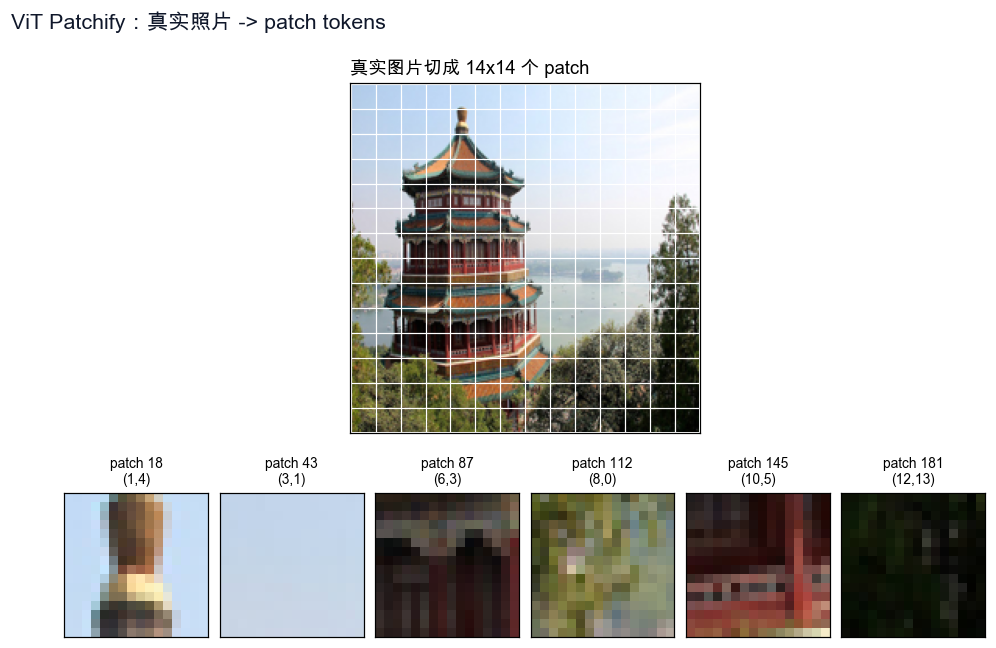

In [3]:
# 绘制真实图片 patch 网格和若干具体 patch。
selected_patches = [18, 43, 87, 112, 145, 181]
fig = plt.figure(figsize=(10.8, 6.6))
gs = fig.add_gridspec(2, 6, height_ratios=[3.4, 1.5], hspace=0.22, wspace=0.08)
ax_img = fig.add_subplot(gs[0, :])
ax_img.imshow(vit_image)
ax_img.set_title("真实图片切成 14x14 个 patch", loc="left", fontweight="bold")
ax_img.set_xticks(np.arange(0, 225, patch_size))
ax_img.set_yticks(np.arange(0, 225, patch_size))
ax_img.grid(color="#ffffff", linewidth=0.8)
ax_img.tick_params(labelbottom=False, labelleft=False, length=0)

for slot, patch_id in enumerate(selected_patches):
    row, col = divmod(patch_id, patch_grid)
    ax = fig.add_subplot(gs[1, slot])
    ax.imshow(patches[row, col])
    ax.set_title(f"patch {patch_id}\n({row},{col})", fontsize=9, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("ViT Patchify：真实照片 -> patch tokens", x=0.08, ha="left", fontsize=14, fontweight="bold", color="#0f172a")
plt.tight_layout()
plt.show()